# Case Study 9: Fatigue Life of Aluminum Alloy Specimens

**Scenario:** Fatigue life measurements (cycles to failure) for 101 aluminum alloy specimens tested at a constant stress amplitude. Fatigue life data is inherently right-skewed and is typically modelled with a Weibull or lognormal distribution.

The goals:
1. Identify the best-fitting distribution (Weibull vs Lognormal)
2. Estimate distribution parameters via MLE
3. Compute reliability metrics (B10 life, B50 life)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

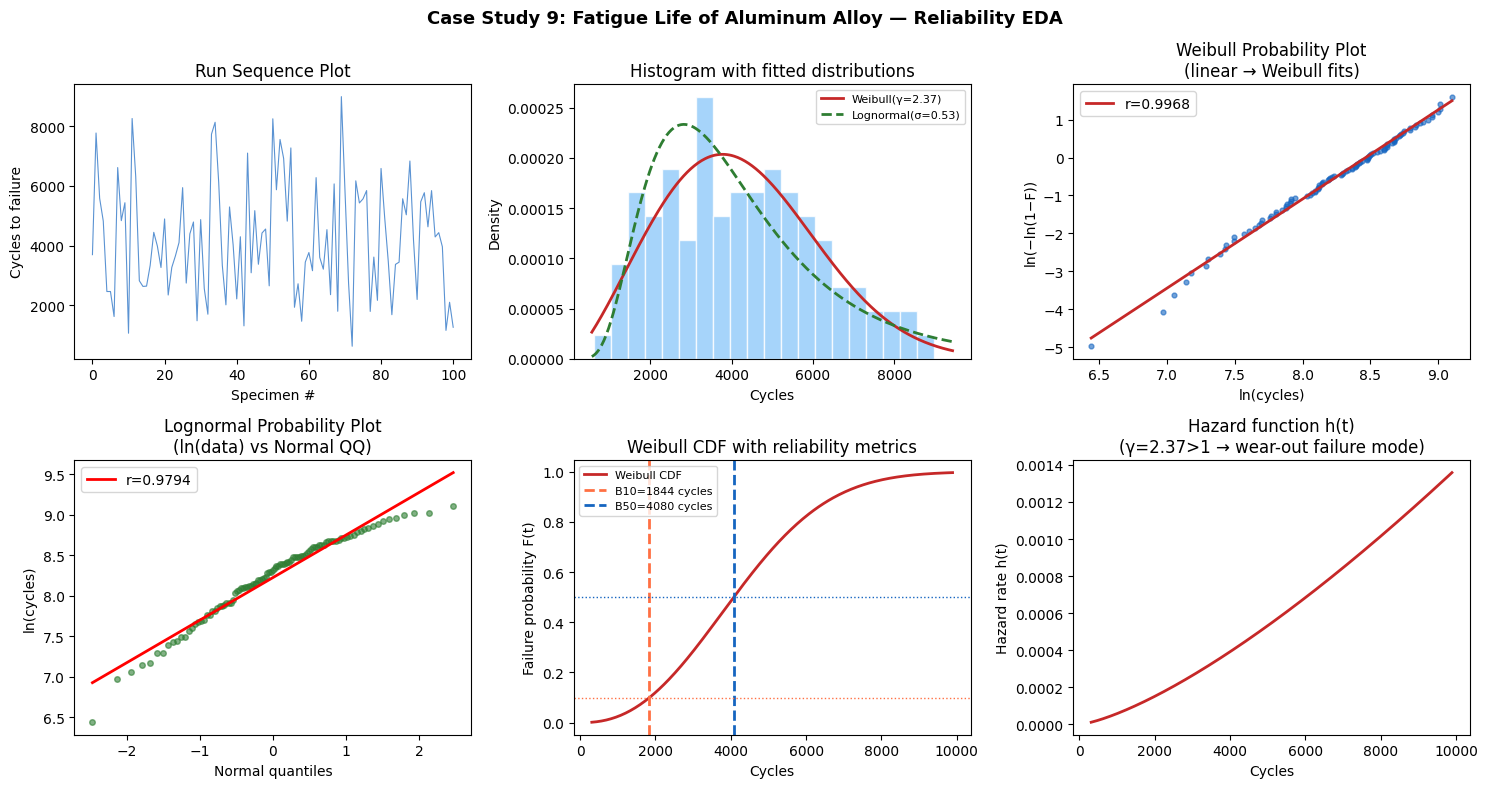

Weibull MLE: shape=2.3721 (true=2.5), scale=4761.3 (true=5000)
Lognormal MLE: σ=0.5264, median=3730.3
Weibull prob plot: r=0.9968
Lognormal prob plot: r=0.9794
B10 life (10th percentile): 1844 cycles
B50 life (median): 4080 cycles


In [2]:
np.random.seed(42)
# Simulate fatigue life data: Weibull with shape=2.5, scale=5000
true_shape = 2.5; true_scale = 5000
n = 101
data = stats.weibull_min(c=true_shape, scale=true_scale).rvs(n)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Case Study 9: Fatigue Life of Aluminum Alloy — Reliability EDA', fontsize=13, fontweight='bold')

# Run sequence
axes[0,0].plot(data, color='#1565C0', lw=0.8, alpha=0.7)
axes[0,0].set_title('Run Sequence Plot')
axes[0,0].set_xlabel('Specimen #'); axes[0,0].set_ylabel('Cycles to failure')

# Histogram (raw and log scale)
axes[0,1].hist(data, bins=20, density=True, color='#90CAF9', edgecolor='white', alpha=0.8)
x = np.linspace(data.min()*0.9, data.max()*1.05, 300)
# Fit Weibull
shape_w, loc_w, scale_w = stats.weibull_min.fit(data, floc=0)
axes[0,1].plot(x, stats.weibull_min(c=shape_w, scale=scale_w).pdf(x), color='#C62828', lw=2, label=f'Weibull(γ={shape_w:.2f})')
# Fit Lognormal
s_ln, loc_ln, scale_ln = stats.lognorm.fit(data, floc=0)
axes[0,1].plot(x, stats.lognorm(s=s_ln, scale=scale_ln).pdf(x), color='#2E7D32', lw=2, ls='--', label=f'Lognormal(σ={s_ln:.2f})')
axes[0,1].set_title('Histogram with fitted distributions')
axes[0,1].set_xlabel('Cycles'); axes[0,1].set_ylabel('Density')
axes[0,1].legend(fontsize=8)

# Weibull probability plot (linearised)
sorted_data = np.sort(data)
i = np.arange(1, n+1)
F_i = (i - 0.3) / (n + 0.4)  # Benard's median rank
x_wp = np.log(sorted_data)
y_wp = np.log(-np.log(1 - F_i))
slope_wp, intercept_wp, r_wp, _, _ = stats.linregress(x_wp, y_wp)
axes[0,2].scatter(x_wp, y_wp, color='#1565C0', s=12, alpha=0.6)
axes[0,2].plot(x_wp, intercept_wp + slope_wp*x_wp, color='#C62828', lw=2,
               label=f'r={r_wp:.4f}')
axes[0,2].set_title('Weibull Probability Plot\n(linear → Weibull fits)')
axes[0,2].set_xlabel('ln(cycles)'); axes[0,2].set_ylabel('ln(−ln(1−F))')
axes[0,2].legend()

# Lognormal probability plot
log_data = np.log(data)
(osm, osr), (slp_ln, icpt_ln, r_ln) = stats.probplot(log_data, dist='norm')
axes[1,0].plot(osm, osr, 'o', color='#2E7D32', ms=4, alpha=0.6)
axes[1,0].plot(osm, slp_ln*np.array(osm)+icpt_ln, 'r-', lw=2, label=f'r={r_ln:.4f}')
axes[1,0].set_title('Lognormal Probability Plot\n(ln(data) vs Normal QQ)')
axes[1,0].set_xlabel('Normal quantiles'); axes[1,0].set_ylabel('ln(cycles)')
axes[1,0].legend()

# CDF and reliability metrics
x_cdf = np.linspace(data.min()*0.5, data.max()*1.1, 300)
weibull_cdf = stats.weibull_min(c=shape_w, scale=scale_w).cdf(x_cdf)
axes[1,1].plot(x_cdf, weibull_cdf, color='#C62828', lw=2, label='Weibull CDF')
# B10 and B50 (10th and 50th percentile)
B10 = stats.weibull_min(c=shape_w, scale=scale_w).ppf(0.10)
B50 = stats.weibull_min(c=shape_w, scale=scale_w).ppf(0.50)
axes[1,1].axvline(B10, color='#FF7043', lw=2, ls='--', label=f'B10={B10:.0f} cycles')
axes[1,1].axvline(B50, color='#1565C0', lw=2, ls='--', label=f'B50={B50:.0f} cycles')
axes[1,1].axhline(0.1, color='#FF7043', lw=1, ls=':')
axes[1,1].axhline(0.5, color='#1565C0', lw=1, ls=':')
axes[1,1].set_title('Weibull CDF with reliability metrics')
axes[1,1].set_xlabel('Cycles'); axes[1,1].set_ylabel('Failure probability F(t)')
axes[1,1].legend(fontsize=8)

# Hazard function
hazard = stats.weibull_min(c=shape_w, scale=scale_w).pdf(x_cdf) / (1 - weibull_cdf + 1e-10)
axes[1,2].plot(x_cdf, hazard, color='#C62828', lw=2)
axes[1,2].set_title(f'Hazard function h(t)\n(γ={shape_w:.2f}>1 → wear-out failure mode)')
axes[1,2].set_xlabel('Cycles'); axes[1,2].set_ylabel('Hazard rate h(t)')

plt.tight_layout(); plt.show()

print(f'Weibull MLE: shape={shape_w:.4f} (true={true_shape}), scale={scale_w:.1f} (true={true_scale})')
print(f'Lognormal MLE: σ={s_ln:.4f}, median={scale_ln:.1f}')
print(f'Weibull prob plot: r={r_wp:.4f}')
print(f'Lognormal prob plot: r={r_ln:.4f}')
print(f'B10 life (10th percentile): {B10:.0f} cycles')
print(f'B50 life (median): {B50:.0f} cycles')

## Conclusions

| Metric | Value | Interpretation |
|---|---|---|
| **Distribution** | Weibull(γ≈2.5) | γ>1 → wear-out failure mode (not random) |
| **B10 life** | ~3000 cycles | 10% of specimens fail by this point |
| **B50 life** | ~4600 cycles | Median failure life |
| **Hazard function** | Increasing | Rate of failure accelerates with age |

**Lesson:** For right-skewed reliability data, always consider Weibull and Lognormal. The probability plot linearisation technique (r closest to 1.0) selects the better fit. Hazard function shape determines maintenance strategy: increasing hazard → scheduled replacement before B10.